# 检查点质量检查

加载指定实验的 `best.pt` 和训练时数据划分，评估验证集指标并可视化正样本局部块的目标曲线预测。修改下面的 `RUN_PATH` 后按顺序运行即可。

In [121]:
from __future__ import annotations

import json
import math
import os
import re
import sys
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch


def locate_method_root() -> Path:
    """兼容从仓库根目录、SimpleCNN 目录或 eval 目录启动 notebook。"""
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "configs" / "base.py").is_file() and (candidate / "train" / "model.py").is_file():
            return candidate
        nested = candidate / "method" / "SimpleCNN"
        if (nested / "configs" / "base.py").is_file():
            return nested
    raise FileNotFoundError("无法从当前工作目录定位 method/SimpleCNN。")


METHOD_ROOT = locate_method_root()
if str(METHOD_ROOT) not in sys.path:
    sys.path.insert(0, str(METHOD_ROOT))

from configs.base import load_config_json
from data.dataloader import (
    PackedSource,
    SourceRecord,
    StandardGridDataset,
    build_validation_dataloader,
    prepare_evaluation_manifest,
    rearrange_distance_channels,
    standard_distance_starts,
)
from eval.evaluator import autocast_context, evaluate_model
from runtime.settings import apply_device_defaults, apply_runtime_settings, load_runtime_settings
from train.model import SimpleCNN
from utils.checkpoint import load_checkpoint
from utils.distributed import setup_distributed
from utils.seed import seed_everything

pd.set_option("display.max_columns", 30)
plt.rcParams.update({
    "figure.dpi": 120,
    "font.sans-serif": ["WenQuanYi Micro Hei", "DejaVu Sans"],
    "axes.unicode_minus": False,
})
print(f"SimpleCNN 根目录：{METHOD_ROOT}")
print(f"PyTorch 版本：{torch.__version__}")

SimpleCNN 根目录：/mnt/host-model/weixc/code/LineTracker/method/SimpleCNN
PyTorch 版本：2.7.1+cpu


In [122]:
# 输入参数；也可用同名 LT_CKPT_CHECK_* 环境变量临时覆盖，便于做小规模冒烟测试。
RUN_PATH = Path(os.environ.get(
    "LT_CKPT_CHECK_RUN_PATH",
    "/mnt/host-model/weixc/code/LineTracker/method/SimpleCNN/runs/simplecnn_v1/"
    "limit20k-gbs512-lr3e-4-pos25-vs5-eval524288-cfgdbdaa574",
)).expanduser()
SPLIT = os.environ.get("LT_CKPT_CHECK_SPLIT", "val")
CHECKPOINT_NAME = os.environ.get("LT_CKPT_CHECK_CHECKPOINT", "best.pt")


def optional_int_env(name: str, default: int | None) -> int | None:
    raw = os.environ.get(name)
    return default if raw is None or raw == "" else int(raw)


# None 表示沿用 resolved_config；EVAL_MAX_BATCHES=0 表示完整遍历固定网格。
EVAL_BATCH_SIZE = optional_int_env("LT_CKPT_CHECK_BATCH_SIZE", None)
EVAL_MAX_BATCHES = optional_int_env("LT_CKPT_CHECK_MAX_BATCHES", None)
EVAL_NUM_WORKERS = optional_int_env("LT_CKPT_CHECK_NUM_WORKERS", 0)
VISUALIZATION_SAMPLES = optional_int_env("LT_CKPT_CHECK_VIS_SAMPLES", 6)
VISUALIZATION_SEED = 20260726
VERIFY_GRID_CACHE = True
REUSE_SAVED_EVAL_BUDGET = True
PLOT_MARGIN_M = 600.0
RANDOM_TEST_SEED = optional_int_env("LT_CKPT_CHECK_TEST_SEED", None)
RANDOM_TEST_TIME_STRIDE = optional_int_env("LT_CKPT_CHECK_TEST_TIME_STRIDE", None)
COMPOSITE_MARGIN_M = 5_000.0
COMPOSITE_POINT_SIZE = 3.0
STITCH_BATCH_SIZE = 64
RANDOM_TEST_SHOW_WINDOW_TOP_N = False
RANDOM_TEST_WINDOW_TOP_N = 3
FRAME_INTERVAL_S = 0.05
PROFILE_WIDTH_M = 1_000

if SPLIT not in {"val", "test"}:
    raise ValueError("SPLIT 必须为 'val' 或 'test'。")
if VISUALIZATION_SAMPLES is None or VISUALIZATION_SAMPLES < 1:
    raise ValueError("VISUALIZATION_SAMPLES 必须为正整数。")
SPLIT_NAME = {"val": "验证集", "test": "测试集"}[SPLIT]

In [123]:
def resolve_run_dir(path: Path, checkpoint_name: str) -> Path:
    """接受具体时间戳目录，或自动选择参数摘要目录下最新的有效运行目录。"""
    path = path.expanduser().resolve()
    if (path / "resolved_config.json").is_file() and (path / "checkpoints" / checkpoint_name).is_file():
        return path
    if not path.is_dir():
        raise FileNotFoundError(f"实验路径不存在：{path}")
    candidates = [
        config_path.parent
        for config_path in path.rglob("resolved_config.json")
        if (config_path.parent / "checkpoints" / checkpoint_name).is_file()
    ]
    if not candidates:
        raise FileNotFoundError(f"{path} 下没有同时包含 resolved_config.json 和 {checkpoint_name} 的运行目录。")
    return max(candidates, key=lambda item: (item.stat().st_mtime_ns, item.name))


run_dir = resolve_run_dir(RUN_PATH, CHECKPOINT_NAME)
checkpoint_path = run_dir / "checkpoints" / CHECKPOINT_NAME
split_path = run_dir / "data" / "split_manifest.json"

runtime_settings = load_runtime_settings()
context = setup_distributed(runtime_settings)
if context.is_distributed:
    raise RuntimeError("该笔记本仅支持单进程运行；请不要通过 torchrun 启动 Jupyter 内核。")

config = load_config_json(run_dir / "resolved_config.json")
config = apply_runtime_settings(config, runtime_settings)
config = apply_device_defaults(config, runtime_settings, context.device.type)
if EVAL_BATCH_SIZE is not None:
    config.eval_batch_size_per_gpu = EVAL_BATCH_SIZE
if EVAL_MAX_BATCHES is not None:
    config.max_eval_batch_num = EVAL_MAX_BATCHES
config.num_workers = int(EVAL_NUM_WORKERS or 0)
config.validate()
seed_everything(config.seed, context.rank)

if not split_path.is_file():
    raise FileNotFoundError(f"训练数据划分不存在：{split_path}")
split_manifest = json.loads(split_path.read_text(encoding="utf-8"))
split_counts = {name: len(items) for name, items in split_manifest["splits"].items()}

manifest_path = prepare_evaluation_manifest(config, run_dir / "data", SPLIT)
eval_dataset = StandardGridDataset(
    manifest_path,
    config,
    verify_cached_samples=VERIFY_GRID_CACHE,
)

display(pd.Series({
    "运行目录": str(run_dir),
    "检查点文件": str(checkpoint_path),
    "计算设备": str(context.device),
    "评估数据划分": SPLIT_NAME,
    "训练数据源数量": split_counts["train"],
    "验证数据源数量": split_counts["val"],
    "测试数据源数量": split_counts["test"],
    "固定网格块总数": len(eval_dataset),
    "正样本局部块数量": int(eval_dataset.is_positive.sum()),
    "单批局部块数量": config.eval_batch_size_per_gpu,
    "配置中的最大评估批次数": config.max_eval_batch_num,
}, name="数值").to_frame())

,数值
运行目录,/mnt/host-model/weixc/code/LineTracker/method/...
检查点文件,/mnt/host-model/weixc/code/LineTracker/method/...
计算设备,npu:0
评估数据划分,验证集
训练数据源数量,16000
验证数据源数量,2000
测试数据源数量,2000
固定网格块总数,3876000
正样本局部块数量,124306
单批局部块数量,512


In [124]:
checkpoint = load_checkpoint(checkpoint_path, context.device)
model = SimpleCNN(config).to(context.device)
model.load_state_dict(checkpoint["model_state"], strict=True)
model.eval()


def saved_eval_block_budget(metric_kind: object) -> int | None:
    """从 checkpoint 指标身份中提取原多卡评估的总块数。"""
    if not isinstance(metric_kind, str):
        return None
    match = re.search(r"(?:^|:)batches=(\d+):batch=(\d+):world=(\d+)(?:$|:)", metric_kind)
    if match is None:
        return None
    batches, batch_size, world_size = (int(value) for value in match.groups())
    return batches * batch_size * world_size


saved_metric_kind = checkpoint.get("best_validation_metric_kind")
saved_eval_blocks = saved_eval_block_budget(saved_metric_kind)
display(pd.Series({
    "保存时的全局步数": checkpoint.get("global_step"),
    "保存的最佳验证损失": checkpoint.get("best_validation_loss"),
    "保存的评估局部块预算": saved_eval_blocks,
    "最佳指标身份": saved_metric_kind,
    "W&B 运行标识": checkpoint.get("wandb_id"),
}, name="数值").to_frame())

,数值
保存时的全局步数,48000
保存的最佳验证损失,646.543569
保存的评估局部块预算,524288
最佳指标身份,resampled_replacement_v1:data=/mnt/host-model/...
W&B 运行标识,pwnn5ek5


In [ ]:
# 数值评估复用训练评估器；默认保持检查点记录的原多卡总评估块预算。
if EVAL_MAX_BATCHES is not None:
    effective_eval_batches = config.max_eval_batch_num
elif REUSE_SAVED_EVAL_BUDGET and saved_eval_blocks is not None:
    effective_eval_batches = math.ceil(saved_eval_blocks / config.eval_batch_size_per_gpu)
else:
    effective_eval_batches = config.max_eval_batch_num

eval_loader = build_validation_dataloader(
    config,
    manifest_path,
    rank=0,
    world_size=1,
    max_eval_batches=effective_eval_batches,
    dataset=eval_dataset,
    num_workers=config.num_workers,
)
evaluated_block_count = len(eval_loader.sampler)
metrics = evaluate_model(model, eval_loader, config, context, prefix=SPLIT_NAME)

metric_labels = {
    f"{SPLIT_NAME}/loss_total": "总损失",
    f"{SPLIT_NAME}/loss_q": "质量分支损失",
    f"{SPLIT_NAME}/loss_line": "轨迹分支损失",
    f"{SPLIT_NAME}/point_mae_bin": "响应点平均绝对误差（距离单元）",
    f"{SPLIT_NAME}/point_rmse_bin": "响应点均方根误差（距离单元）",
    f"{SPLIT_NAME}/q_mae": "质量值平均绝对误差",
    f"{SPLIT_NAME}/q_rmse": "质量值均方根误差",
    f"{SPLIT_NAME}/blocks": "评估局部块数量",
    f"{SPLIT_NAME}/visible_positive_blocks": "可见正样本块数量",
    f"{SPLIT_NAME}/line_supervised_blocks": "轨迹监督块数量",
    f"{SPLIT_NAME}/labeled_points": "有标签响应点数量",
}
metric_table = pd.DataFrame(
    [(metric_labels.get(name, name), value) for name, value in metrics.items()],
    columns=["指标", "数值"],
).set_index("指标")
display(metric_table)
print(f"本次实际评估 {evaluated_block_count:,} 个局部块，共 {len(eval_loader):,} 个批次。")
if saved_eval_blocks is not None and EVAL_MAX_BATCHES is None:
    print("使用与检查点相同的总样本预算做全新有放回抽样；这是独立质量复核，不是训练时样本的逐项重放。")

In [125]:
# 从评估固定网格的正样本中确定性抽样，并执行一次批量预测。
positive_indices = np.flatnonzero(eval_dataset.is_positive)
if len(positive_indices) == 0:
    raise RuntimeError(f"{SPLIT} 固定网格中没有正样本。")
sample_count = min(int(VISUALIZATION_SAMPLES), len(positive_indices))
rng = np.random.default_rng(VISUALIZATION_SEED)
selected_indices = rng.choice(positive_indices, size=sample_count, replace=False)
selected_samples = [eval_dataset[int(index)] for index in selected_indices]
model_input = torch.stack([sample["x"] for sample in selected_samples]).to(
    context.device,
    non_blocking=True,
)

with torch.inference_mode(), autocast_context(config, context.device):
    visualization_prediction = model(model_input)
prediction_cpu = {
    name: tensor.detach().float().cpu().numpy()
    for name, tensor in visualization_prediction.items()
}

true_range_cache: dict[int, np.ndarray] = {}
frame_index = np.arange(config.frames_per_window, dtype=np.float32)
tau_zero = (config.frames_per_window - 1) / 2.0
visualization_records: list[dict[str, object]] = []

for slot, (manifest_index, sample) in enumerate(zip(selected_indices, selected_samples, strict=True)):
    manifest_index = int(manifest_index)
    source_index = int(eval_dataset.source_index[manifest_index])
    time_start = int(eval_dataset.time_start[manifest_index])
    range_start = int(eval_dataset.range_start[manifest_index])
    if source_index not in true_range_cache:
        with np.load(eval_dataset.source_paths[source_index], allow_pickle=False) as archive:
            true_range_cache[source_index] = archive["target_true_range_m"].astype(np.float32, copy=True)

    true_curve_local_m = (
        true_range_cache[source_index][time_start : time_start + config.frames_per_window]
        - range_start
    )
    predicted_curve_local_m = (
        prediction_cpu["rho_m"][slot]
        + prediction_cpu["nu_mpf"][slot] * (frame_index - tau_zero)
    )
    response_mask = sample["I"].numpy().astype(bool, copy=False)
    response_bin = sample["d"].numpy()
    response_mae = float(np.mean(np.abs(
        predicted_curve_local_m[response_mask] - response_bin[response_mask]
    )))
    true_curve_mae = float(np.mean(np.abs(predicted_curve_local_m - true_curve_local_m)))
    raw_window = sample["x"].numpy().transpose(1, 2, 0).reshape(
        config.frames_per_window,
        config.block_width_m,
    )
    visualization_records.append({
        "manifest_index": manifest_index,
        "source_id": eval_dataset.source_ids[source_index],
        "time_start": time_start,
        "range_start_m": range_start,
        "q_target": float(sample["q"].item()),
        "q_prediction": float(prediction_cpu["q"][slot]),
        "rho_prediction_m": float(prediction_cpu["rho_m"][slot]),
        "nu_prediction_mpf": float(prediction_cpu["nu_mpf"][slot]),
        "response_mae_bin": response_mae,
        "true_curve_mae_m": true_curve_mae,
        "raw_window": raw_window,
        "response_mask": response_mask,
        "response_bin": response_bin,
        "true_curve_local_m": true_curve_local_m,
        "predicted_curve_local_m": predicted_curve_local_m,
    })

visualization_table = pd.DataFrame(visualization_records).drop(columns=[
    "raw_window",
    "response_mask",
    "response_bin",
    "true_curve_local_m",
    "predicted_curve_local_m",
]).rename(columns={
    "manifest_index": "网格索引",
    "source_id": "数据源标识",
    "time_start": "起始帧",
    "range_start_m": "局部块起始距离（米）",
    "q_target": "真实质量值",
    "q_prediction": "预测质量值",
    "rho_prediction_m": "预测中心距离（米）",
    "nu_prediction_mpf": "预测每帧速度（米/帧）",
    "response_mae_bin": "响应点平均绝对误差（距离单元）",
    "true_curve_mae_m": "完整轨迹平均绝对误差（米）",
})
display(visualization_table.round(4))

,网格索引,数据源标识,起始帧,局部块起始距离（米）,真实质量值,预测质量值,预测中心距离（米）,预测每帧速度（米/帧）,响应点平均绝对误差（距离单元）,完整轨迹平均绝对误差（米）
0,3867850,dataset1_synthetic_16098,225,90000,0.25,0.0255,7680.0,2.3281,6991.1670,6992.7938
1,2270097,dataset1_synthetic_11273,100,171000,0.30,0.2500,8512.0,-6.0625,69.4167,62.0070
2,537863,dataset1_synthetic_12346,150,153000,0.50,0.5859,8192.0,6.8438,29.3406,29.2797
3,2745996,dataset1_synthetic_13499,260,180000,0.50,0.6016,5472.0,4.1562,18.1031,16.5867
4,3372268,dataset1_synthetic_12285,20,108000,0.90,0.6875,3168.0,-0.7734,18.3837,18.3766
5,746190,dataset1_synthetic_2385,5,234000,0.55,0.5742,9088.0,12.0000,49.6364,47.3641


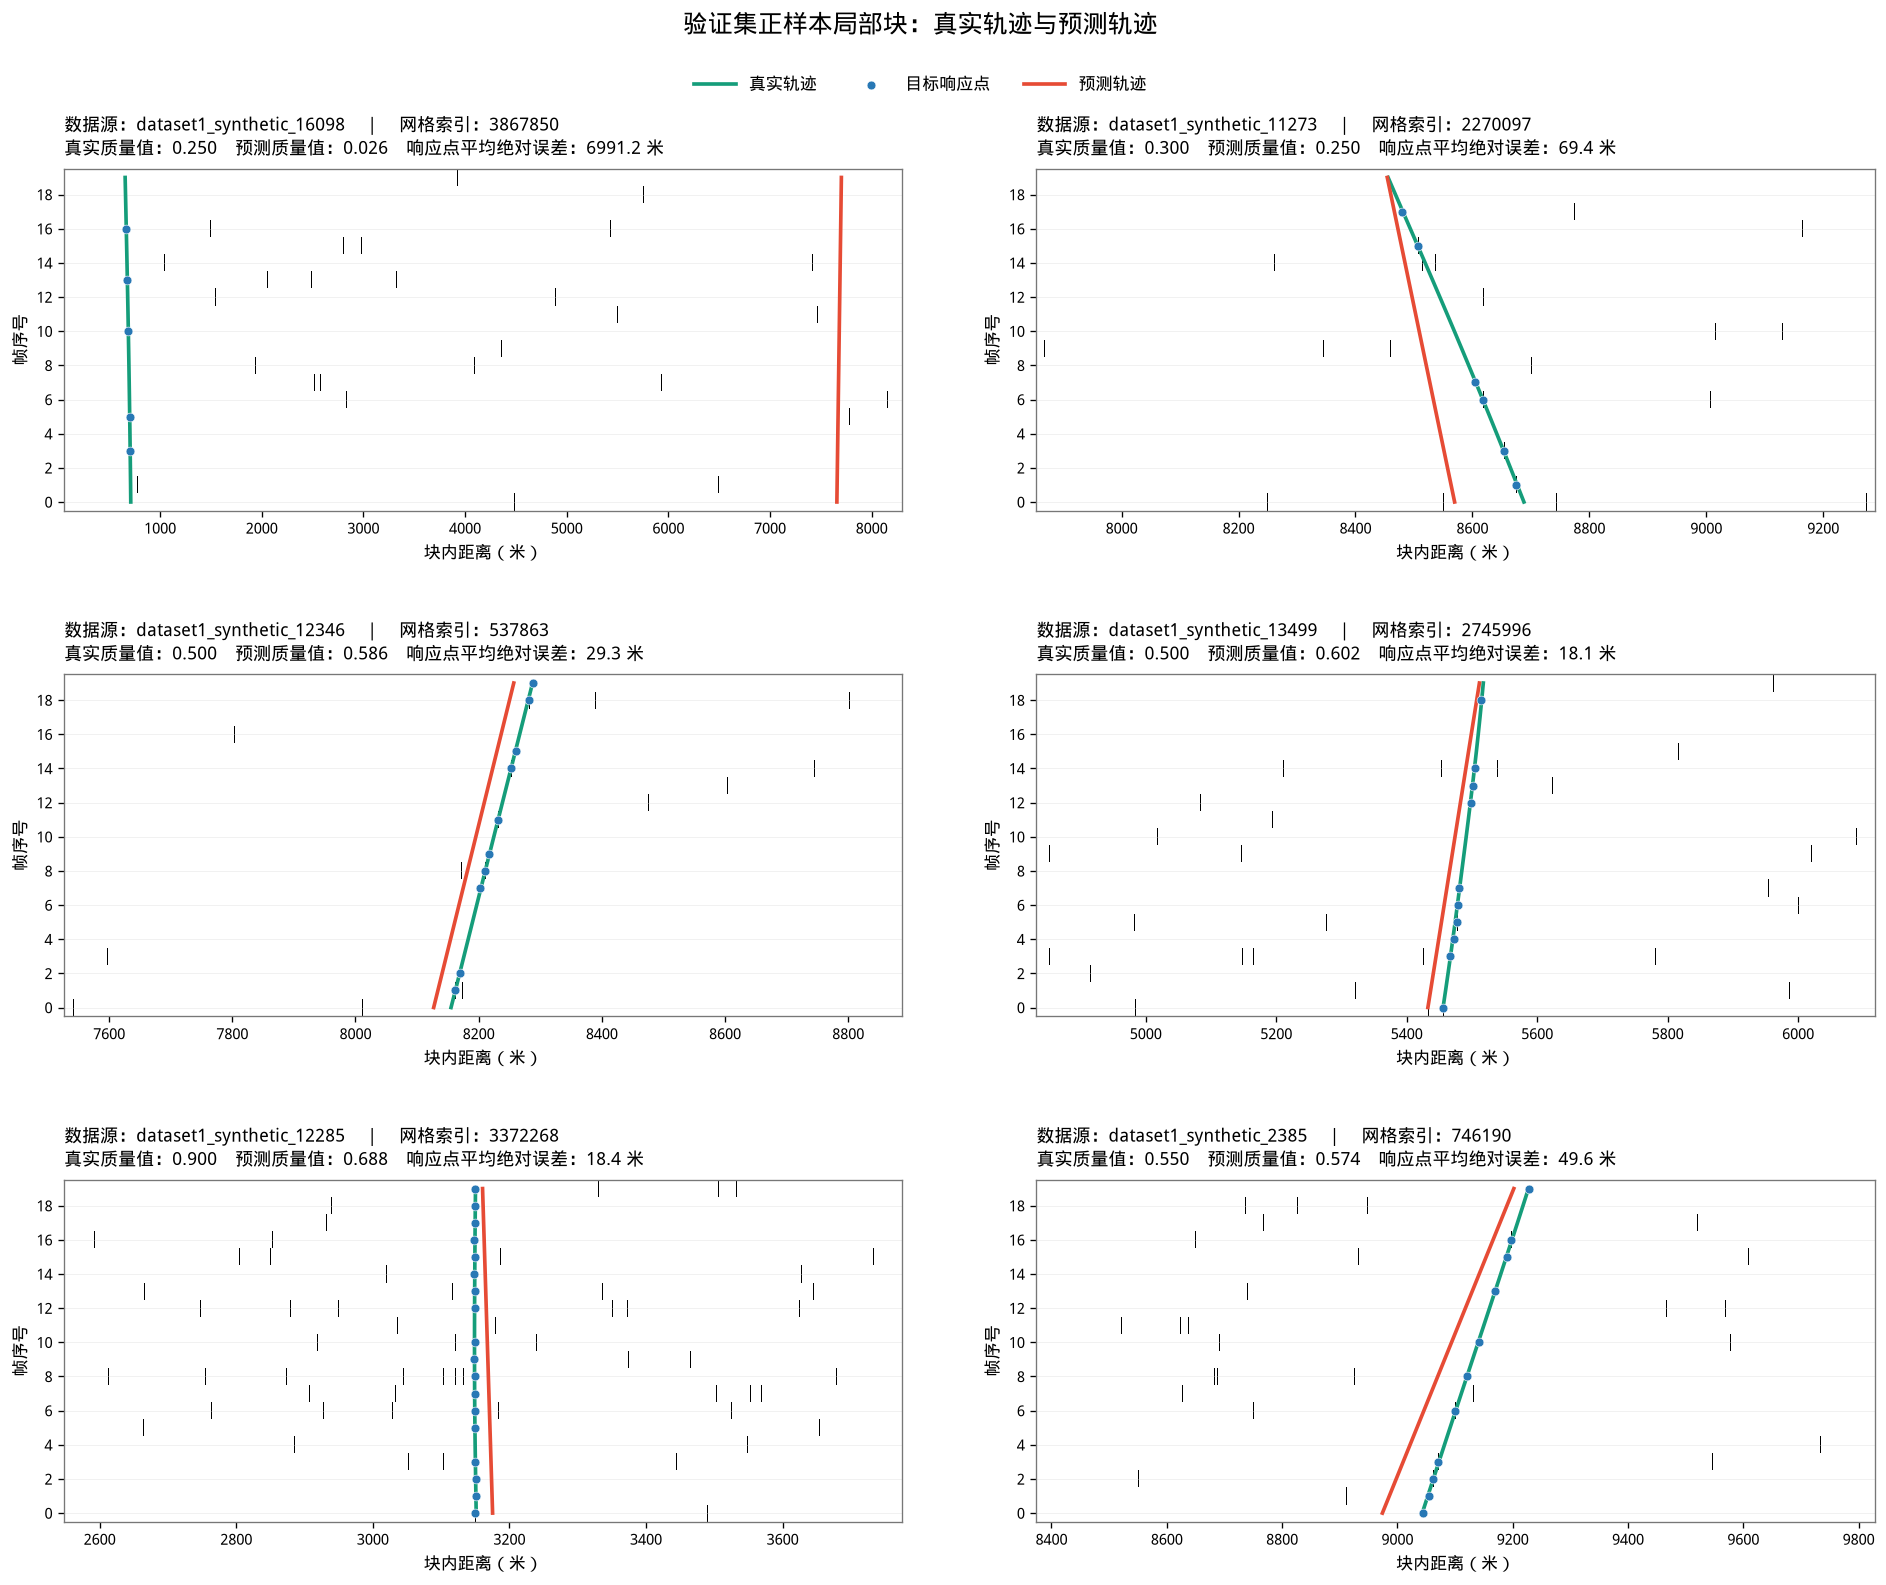

In [126]:
# 灰度底图为局部二值观测，绿线为完整真实轨迹，蓝点为实际响应，红线为预测轨迹。
column_count = min(2, len(visualization_records))
row_count = math.ceil(len(visualization_records) / column_count)
figure, axes = plt.subplots(
    row_count,
    column_count,
    figsize=(8.2 * column_count, 4.2 * row_count + 0.9),
    squeeze=False,
)

for axis, record in zip(axes.flat, visualization_records, strict=False):
    axis.imshow(
        record["raw_window"],
        origin="lower",
        aspect="auto",
        interpolation="nearest",
        cmap="gray_r",
        vmin=0,
        vmax=1,
        extent=(0, config.block_width_m, -0.5, config.frames_per_window - 0.5),
        rasterized=True,
    )
    axis.plot(
        record["true_curve_local_m"],
        frame_index,
        color="#159D7A",
        linewidth=2.2,
        label="真实轨迹",
        zorder=3,
    )
    axis.scatter(
        record["response_bin"][record["response_mask"]],
        frame_index[record["response_mask"]],
        color="#2878B5",
        edgecolor="white",
        linewidth=0.35,
        s=28,
        marker="o",
        label="目标响应点",
        zorder=4,
    )
    axis.plot(
        record["predicted_curve_local_m"],
        frame_index,
        color="#E64B35",
        linewidth=2.2,
        label="预测轨迹",
        zorder=3,
    )

    focus_values = np.concatenate((
        np.asarray(record["true_curve_local_m"]),
        np.asarray(record["predicted_curve_local_m"]),
        np.asarray(record["response_bin"])[np.asarray(record["response_mask"])],
    ))
    left = max(0.0, float(np.min(focus_values)) - PLOT_MARGIN_M)
    right = min(float(config.block_width_m), float(np.max(focus_values)) + PLOT_MARGIN_M)
    if right - left < 2.0 * PLOT_MARGIN_M:
        center = 0.5 * (left + right)
        left = max(0.0, center - PLOT_MARGIN_M)
        right = min(float(config.block_width_m), center + PLOT_MARGIN_M)

    axis.set_xlim(left, right)
    axis.set_ylim(-0.5, config.frames_per_window - 0.5)
    axis.set_xlabel("块内距离（米）", fontsize=10)
    axis.set_ylabel("帧序号", fontsize=10)
    axis.set_yticks(np.arange(0, config.frames_per_window, 2))
    axis.tick_params(axis="both", labelsize=9)
    axis.grid(axis="y", color="#D9D9D9", linewidth=0.6, alpha=0.35)
    axis.set_title(
        f"数据源：{record['source_id']}　｜　网格索引：{record['manifest_index']}\n"
        f"真实质量值：{record['q_target']:.3f}　预测质量值：{record['q_prediction']:.3f}　"
        f"响应点平均绝对误差：{record['response_mae_bin']:.1f} 米",
        fontsize=10.5,
        loc="left",
        pad=9,
        linespacing=1.25,
    )
    for spine in axis.spines.values():
        spine.set_color("#777777")
        spine.set_linewidth(0.8)

for axis in axes.flat[len(visualization_records):]:
    axis.set_visible(False)

handles, labels = axes.flat[0].get_legend_handles_labels()
figure.suptitle(
    f"{SPLIT_NAME}正样本局部块：真实轨迹与预测轨迹",
    fontsize=15,
    fontweight="normal",
    y=0.992,
)
figure.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.962),
    ncol=3,
    frameon=False,
    fontsize=10,
    handlelength=2.5,
    columnspacing=2.0,
)
figure.subplots_adjust(
    left=0.065,
    right=0.985,
    bottom=0.06,
    top=0.895,
    hspace=0.48,
    wspace=0.16,
)
plt.show()

In [127]:
# 按时间窗步进懒加载固定 test 网格；切换步进时释放上一份大 dataset。
_test_dataset_cache: dict[int, tuple[object, StandardGridDataset, np.ndarray]] = {}


def get_test_dataset(
    time_stride: int | None,
) -> tuple[object, StandardGridDataset, np.ndarray]:
    """返回指定时间窗步进的 test 配置、dataset 和含正样本的数据源索引。"""
    effective_stride = config.validation_time_stride if time_stride is None else int(time_stride)
    if effective_stride < 1:
        raise ValueError("time_stride 必须为正整数。")
    cached = _test_dataset_cache.get(effective_stride)
    if cached is not None:
        return cached

    test_config = replace(config, validation_time_stride=effective_stride)
    print(f"正在准备时间窗步进为 {effective_stride} 帧的测试集固定网格……")
    if SPLIT == "test" and effective_stride == config.validation_time_stride:
        test_dataset = eval_dataset
    else:
        test_manifest_path = prepare_evaluation_manifest(
            test_config,
            run_dir / "data",
            "test",
        )
        test_dataset = StandardGridDataset(
            test_manifest_path,
            test_config,
            verify_cached_samples=VERIFY_GRID_CACHE,
        )
    positive_source_indices = np.asarray([
        source_index
        for source_index, (source_start, source_stop) in enumerate(test_dataset.source_spans)
        if np.any(test_dataset.is_positive[source_start:source_stop])
    ], dtype=np.int32)
    if len(positive_source_indices) == 0:
        raise RuntimeError("测试集中没有包含正样本局部块的数据源。")

    _test_dataset_cache.clear()
    result = (test_config, test_dataset, positive_source_indices)
    _test_dataset_cache[effective_stride] = result
    print(
        f"测试集共有 {len(test_dataset.source_ids):,} 个数据源，其中 "
        f"{len(positive_source_indices):,} 个可用于随机轨迹拟合检查。"
    )
    return result


def plot_test_source_fit(
    source_index: int,
    *,
    time_stride: int | None = None,
    margin_m: float = COMPOSITE_MARGIN_M,
    point_size: float = COMPOSITE_POINT_SIZE,
    stitch_batch_size: int = STITCH_BATCH_SIZE,
    show_window_top_n: bool = False,
    window_top_n: int = 3,
) -> tuple[dict[str, object], plt.Figure]:
    """绘制一个测试数据源的 2×2 拟合诊断图。"""
    test_config, test_dataset, _ = get_test_dataset(time_stride)
    if not 0 <= source_index < len(test_dataset.source_ids):
        raise IndexError(f"测试数据源索引越界：{source_index}")
    if margin_m < 0.0 or point_size <= 0.0 or stitch_batch_size < 1:
        raise ValueError("绘图边距必须非负，点大小和拼接批大小必须为正。")
    if not isinstance(show_window_top_n, (bool, np.bool_)):
        raise TypeError("show_window_top_n 必须是布尔值。")
    standard_grid_count = len(standard_distance_starts(test_config))
    if show_window_top_n and not 1 <= window_top_n <= standard_grid_count:
        raise ValueError(
            f"开启逐时间窗 Top-N 时，window_top_n 应位于 [1, {standard_grid_count}]，"
            f"实际为 {window_top_n}。"
        )
    composite_source_index = int(source_index)
    composite_source_id = test_dataset.source_ids[composite_source_index]
    composite_source_path = test_dataset.source_paths[composite_source_index]
    local_frame_index = np.arange(config.frames_per_window, dtype=np.float32)
    local_tau_zero = (config.frames_per_window - 1) / 2.0
    with np.load(composite_source_path, allow_pickle=False) as archive:
        background_packed = archive["background_only_packed"].astype(np.uint8, copy=True)
        observation_packed = archive["observation_packed"].astype(np.uint8, copy=True)
        background_probability_1m = archive["background_probability_1m"].astype(np.float64, copy=True)
        source_true_range_m = archive["target_true_range_m"].astype(np.float64, copy=True)
        source_target_hit = archive["target_hit"].astype(bool, copy=True)
        source_target_hit_bin = archive["target_hit_bin"].astype(np.int64, copy=True)


    def unpack_local_range(packed: np.ndarray, range_start: int, range_stop: int) -> np.ndarray:
        """只解包绘图需要的局部距离范围。"""
        first_byte = range_start // 8
        bit_offset = range_start % 8
        width = range_stop - range_start
        byte_count = math.ceil((bit_offset + width) / 8)
        unpacked = np.unpackbits(
            packed[:, first_byte : first_byte + byte_count],
            axis=1,
            bitorder=config.packed_bitorder,
        )
        return unpacked[:, bit_offset : bit_offset + width]


    frame_count = int(background_packed.shape[0])
    window_start = max(0, int(np.floor(source_true_range_m.min() - margin_m)))
    window_stop = min(config.range_bins, int(np.ceil(source_true_range_m.max() + margin_m + 1.0)))
    local_background = unpack_local_range(background_packed, window_start, window_stop)
    local_observation = unpack_local_range(observation_packed, window_start, window_stop)
    background_frames, background_bins = np.nonzero(local_background)
    observation_frames, observation_bins = np.nonzero(local_observation)

    time_seconds = np.arange(frame_count, dtype=np.float64) * FRAME_INTERVAL_S
    true_range_km = source_true_range_m / 1_000.0
    hit_range_km = source_target_hit_bin[source_target_hit] / 1_000.0
    local_range_limits_km = (window_start / 1_000.0, window_stop / 1_000.0)
    background_probability_1km = background_probability_1m.reshape(-1, PROFILE_WIDTH_M).mean(axis=1)
    background_centres_km = np.arange(background_probability_1km.size, dtype=np.float64) + 0.5

    # 默认只推理正样本块；开启逐窗 Top-N 后推理全部标准网格，并复用其中的正样本结果做轨迹拼接。
    source_span_start, source_span_stop = test_dataset.source_spans[composite_source_index]
    source_manifest_indices = np.arange(source_span_start, source_span_stop, dtype=np.int64)
    source_positive_mask = test_dataset.is_positive[source_span_start:source_span_stop]
    source_positive_indices = source_manifest_indices[source_positive_mask]
    if len(source_positive_indices) == 0:
        raise RuntimeError(f"数据源 {composite_source_id} 没有可用于轨迹拼接的正样本局部块。")

    inference_indices = source_manifest_indices if show_window_top_n else source_positive_indices
    source_prediction_q = (
        np.empty(len(source_manifest_indices), dtype=np.float32)
        if show_window_top_n
        else None
    )
    source_prediction_rho = (
        np.empty(len(source_manifest_indices), dtype=np.float32)
        if show_window_top_n
        else None
    )
    source_prediction_nu = (
        np.empty(len(source_manifest_indices), dtype=np.float32)
        if show_window_top_n
        else None
    )
    stitched_weighted_sum = np.zeros(frame_count, dtype=np.float64)
    stitched_weight_sum = np.zeros(frame_count, dtype=np.float64)
    for chunk_start in range(0, len(inference_indices), stitch_batch_size):
        chunk_indices = inference_indices[chunk_start : chunk_start + stitch_batch_size]
        chunk_samples = [test_dataset[int(index)] for index in chunk_indices]
        chunk_input = torch.stack([sample["x"] for sample in chunk_samples]).to(
            context.device,
            non_blocking=True,
        )
        with torch.inference_mode(), autocast_context(config, context.device):
            chunk_prediction = model(chunk_input)
        chunk_q = chunk_prediction["q"].detach().float().cpu().numpy()
        chunk_rho = chunk_prediction["rho_m"].detach().float().cpu().numpy()
        chunk_nu = chunk_prediction["nu_mpf"].detach().float().cpu().numpy()

        for local_slot, manifest_index in enumerate(chunk_indices):
            manifest_index = int(manifest_index)
            source_slot = manifest_index - source_span_start
            if show_window_top_n:
                source_prediction_q[source_slot] = chunk_q[local_slot]
                source_prediction_rho[source_slot] = chunk_rho[local_slot]
                source_prediction_nu[source_slot] = chunk_nu[local_slot]
            if not source_positive_mask[source_slot]:
                continue

            time_start = int(test_dataset.time_start[manifest_index])
            range_start = int(test_dataset.range_start[manifest_index])
            global_frames = np.arange(time_start, time_start + config.frames_per_window, dtype=np.int64)
            predicted_global_range_m = (
                range_start
                + chunk_rho[local_slot]
                + chunk_nu[local_slot] * (local_frame_index - local_tau_zero)
            )
            quality_weight = max(float(chunk_q[local_slot]), 1e-6)
            stitched_weighted_sum[global_frames] += predicted_global_range_m * quality_weight
            stitched_weight_sum[global_frames] += quality_weight

    window_top_n_segments: list[tuple[np.ndarray, np.ndarray, float]] = []
    if show_window_top_n:
        source_time_starts = test_dataset.time_start[source_span_start:source_span_stop]
        source_range_starts = test_dataset.range_start[source_span_start:source_span_stop]
        for window_time_start in np.unique(source_time_starts):
            window_slots = np.flatnonzero(source_time_starts == window_time_start)
            ranked_window_slots = window_slots[
                np.argsort(-source_prediction_q[window_slots], kind="stable")[:window_top_n]
            ]
            window_top_q = float(source_prediction_q[ranked_window_slots[0]])
            segment_time_seconds = (
                int(window_time_start) + local_frame_index
            ) * FRAME_INTERVAL_S
            for source_slot in ranked_window_slots:
                q_value = float(source_prediction_q[source_slot])
                line_alpha = (
                    float(np.clip(q_value / window_top_q, 0.0, 1.0))
                    if window_top_q > 0.0
                    else 1.0
                )
                predicted_global_range_km = (
                    source_range_starts[source_slot]
                    + source_prediction_rho[source_slot]
                    + source_prediction_nu[source_slot]
                    * (local_frame_index - local_tau_zero)
                ) / 1_000.0
                window_top_n_segments.append((
                    segment_time_seconds,
                    predicted_global_range_km,
                    line_alpha,
                ))

    stitched_prediction_m = np.full(frame_count, np.nan, dtype=np.float64)
    covered_frames = stitched_weight_sum > 0.0
    stitched_prediction_m[covered_frames] = stitched_weighted_sum[covered_frames] / stitched_weight_sum[covered_frames]
    stitched_mae_m = float(np.mean(np.abs(stitched_prediction_m[covered_frames] - source_true_range_m[covered_frames])))
    stitched_coverage = float(covered_frames.mean())
    prediction_plot_limits_km = local_range_limits_km
    if window_top_n_segments:
        top_n_min_km = min(float(segment_range.min()) for _, segment_range, _ in window_top_n_segments)
        top_n_max_km = max(float(segment_range.max()) for _, segment_range, _ in window_top_n_segments)
        prediction_plot_limits_km = (
            max(0.0, min(local_range_limits_km[0], top_n_min_km - 1.0)),
            min(config.range_bins / 1_000.0, max(local_range_limits_km[1], top_n_max_km + 1.0)),
        )

    # 2×2 综合图：背景概率、未标注观测、真实轨迹和预测拼接轨迹。
    figure_2x2, axes_2x2 = plt.subplots(2, 2, figsize=(16, 9.5), layout="constrained")
    figure_2x2.suptitle(
        f"测试集随机样本目标轨迹综合诊断：{composite_source_id}",
        fontsize=15,
        fontweight="normal",
    )

    axes_2x2[0, 0].semilogy(
        background_centres_km,
        background_probability_1km,
        color="#4C78A8",
        linewidth=1.4,
    )
    axes_2x2[0, 0].axvspan(
        true_range_km.min(), true_range_km.max(),
        color="#E64B35", alpha=0.16, label="本次目标经过距离",
    )
    axes_2x2[0, 0].set(
        title="拟合模型恢复的背景占据概率",
        xlabel="距离（千米）",
        ylabel="每米距离单元的占据概率",
        xlim=(0, config.range_bins / 1_000.0),
    )
    axes_2x2[0, 0].legend(fontsize=8)

    axes_2x2[0, 1].scatter(
        time_seconds[observation_frames],
        (window_start + observation_bins) / 1_000.0,
        s=point_size, marker="s", linewidths=0,
        alpha=0.8, color="#4C9AD4", rasterized=True,
        label="二值响应（目标未标注）",
    )
    axes_2x2[0, 1].set(
        title="含目标的局部二值时距图（未标注）",
        xlabel="时间（秒）", ylabel="距离（千米）", ylim=local_range_limits_km,
    )
    axes_2x2[0, 1].grid(alpha=0.22)
    axes_2x2[0, 1].legend(fontsize=8)

    axes_2x2[1, 0].scatter(
        time_seconds[background_frames],
        (window_start + background_bins) / 1_000.0,
        s=point_size, marker="s", linewidths=0,
        alpha=0.72, color="#4C9AD4", rasterized=True, label="背景响应",
    )
    axes_2x2[1, 0].plot(
        time_seconds, true_range_km,
        color="#202124", linewidth=1.3, label="真实潜在轨迹",
    )
    axes_2x2[1, 0].scatter(
        time_seconds[source_target_hit], hit_range_km,
        s=10, color="#E64B35", zorder=3, label="实际目标响应",
    )
    axes_2x2[1, 0].set(
        title="纯背景叠加真实目标轨迹",
        xlabel="时间（秒）", ylabel="距离（千米）", ylim=local_range_limits_km,
    )
    axes_2x2[1, 0].grid(alpha=0.22)
    axes_2x2[1, 0].legend(fontsize=8)

    axes_2x2[1, 1].scatter(
        time_seconds[background_frames],
        (window_start + background_bins) / 1_000.0,
        s=point_size, marker="s", linewidths=0,
        alpha=0.62, color="#4C9AD4", rasterized=True, label="背景响应",
    )
    axes_2x2[1, 1].plot(
        time_seconds, true_range_km,
        color="#666666", linewidth=1.1, linestyle="--", alpha=0.9,
        label="真实轨迹（对照）",
    )
    for segment_index, (segment_time, segment_range, line_alpha) in enumerate(window_top_n_segments):
        axes_2x2[1, 1].plot(
            segment_time,
            segment_range,
            color="#0072B2",
            linewidth=1.0,
            alpha=line_alpha,
            label="各时间窗 q Top-N 预测线" if segment_index == 0 else None,
            zorder=2,
        )
    axes_2x2[1, 1].plot(
        time_seconds[covered_frames], stitched_prediction_m[covered_frames] / 1_000.0,
        color="#E64B35", linewidth=2.0, label="质量值加权拼接预测轨迹", zorder=3,
    )
    axes_2x2[1, 1].set(
        title=(
            "正样本局部块预测轨迹拼接"
            f"（平均绝对误差 {stitched_mae_m:.1f} 米，覆盖率 {stitched_coverage:.1%}）"
        ),
        xlabel="时间（秒）", ylabel="距离（千米）", ylim=prediction_plot_limits_km,
    )
    axes_2x2[1, 1].grid(alpha=0.22)
    axes_2x2[1, 1].legend(fontsize=8)

    for axis in axes_2x2.flat:
        axis.tick_params(axis="both", labelsize=9)
        axis.title.set_fontsize(11)
        for spine in axis.spines.values():
            spine.set_color("#777777")
            spine.set_linewidth(0.8)

    summary = {
        "数据划分": "测试集",
        "数据源索引": composite_source_index,
        "数据源标识": composite_source_id,
        "时间窗步进（帧）": int(test_config.validation_time_stride),
        "参与拼接的正样本局部块数量": int(len(source_positive_indices)),
        "逐时间窗 Top-N 预测线": "开启" if show_window_top_n else "关闭",
        "每个时间窗显示数量": int(window_top_n) if show_window_top_n else 0,
        "本次模型推理局部块数量": int(len(inference_indices)),
        "预测轨迹覆盖帧数": int(covered_frames.sum()),
        "预测轨迹覆盖率": stitched_coverage,
        "拼接预测轨迹平均绝对误差（米）": stitched_mae_m,
    }
    plt.show()
    return summary, figure_2x2


def plot_random_test_sample_fit(
    *,
    time_stride: int | None = None,
    seed: int | None = None,
    margin_m: float = COMPOSITE_MARGIN_M,
    point_size: float = COMPOSITE_POINT_SIZE,
    stitch_batch_size: int = STITCH_BATCH_SIZE,
    show_window_top_n: bool = False,
    window_top_n: int = 3,
) -> tuple[dict[str, object], plt.Figure]:
    """随机选择测试数据源；可选显示每个时间窗按 q 排名的 Top-N 预测线。"""
    _, _, positive_source_indices = get_test_dataset(time_stride)
    random_generator = np.random.default_rng(seed)
    source_index = int(random_generator.choice(positive_source_indices))
    return plot_test_source_fit(
        source_index,
        time_stride=time_stride,
        margin_m=margin_m,
        point_size=point_size,
        stitch_batch_size=stitch_batch_size,
        show_window_top_n=show_window_top_n,
        window_top_n=window_top_n,
    )


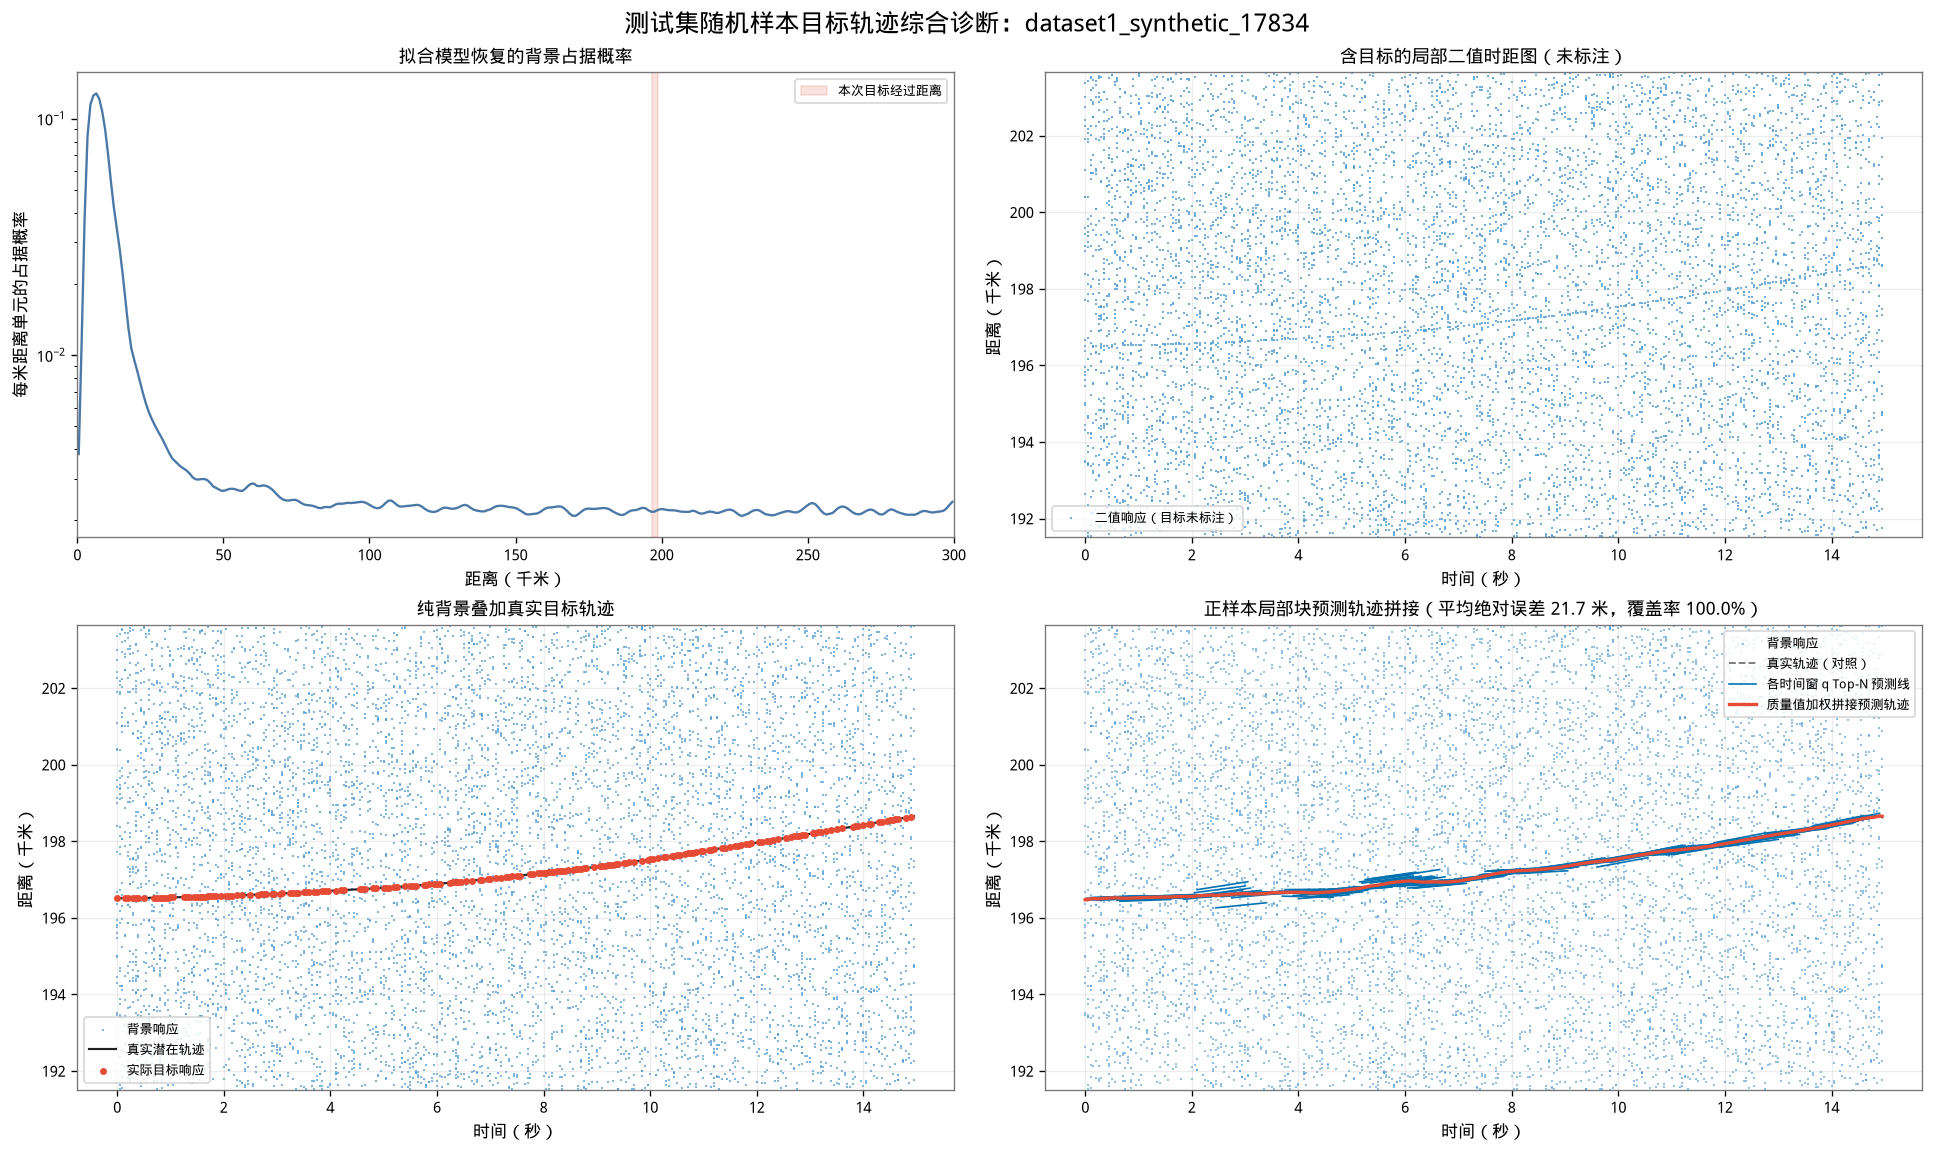

,数值
数据划分,测试集
数据源索引,750
数据源标识,dataset1_synthetic_17834
时间窗步进（帧）,1
参与拼接的正样本局部块数量,318
逐时间窗 Top-N 预测线,开启
每个时间窗显示数量,1
本次模型推理局部块数量,9554
预测轨迹覆盖帧数,300
预测轨迹覆盖率,1.0


In [135]:
# 重复运行本单元格即可从 test 集重新随机选择一个样本。
random_test_summary, random_test_figure = plot_random_test_sample_fit(
    time_stride=1,
    seed=RANDOM_TEST_SEED,
    show_window_top_n=True,
    window_top_n=1,
)
display(pd.Series(random_test_summary, name="数值").to_frame())


In [129]:
def plot_test_window_top_q(
    source_index: int,
    time_start: int,
    *,
    top_n: int = 5,
) -> tuple[pd.DataFrame, plt.Figure]:
    """对测试样本指定时间窗的全部标准距离网格预测，打印 q 排序并绘制 Top-N 轨迹。"""
    _, test_dataset, _ = get_test_dataset(None)
    if not 0 <= source_index < len(test_dataset.source_ids):
        raise IndexError(
            f"测试样本索引应位于 [0, {len(test_dataset.source_ids) - 1}]，实际为 {source_index}。"
        )

    source_record = SourceRecord(
        source_id=test_dataset.source_ids[source_index],
        path=test_dataset.source_paths[source_index],
    )
    source = PackedSource(source_record)
    maximum_time_start = source.frames - config.frames_per_window
    if not 0 <= time_start <= maximum_time_start:
        raise IndexError(
            f"时间窗起始帧应位于 [0, {maximum_time_start}]，实际为 {time_start}。"
        )

    range_starts = np.asarray(standard_distance_starts(config), dtype=np.int64)
    if not 1 <= top_n <= len(range_starts):
        raise ValueError(f"top_n 应位于 [1, {len(range_starts)}]，实际为 {top_n}。")

    model_inputs = []
    for range_start in range_starts:
        raw_window = source.extract_window(time_start, int(range_start), config)
        rearranged = rearrange_distance_channels(raw_window, config)
        model_inputs.append(torch.from_numpy(rearranged.astype(np.float32, copy=False)))
    model_input = torch.stack(model_inputs).to(context.device, non_blocking=True)

    with torch.inference_mode(), autocast_context(config, context.device):
        prediction = model(model_input)
    predicted_q = prediction["q"].detach().float().cpu().numpy()
    predicted_rho_m = prediction["rho_m"].detach().float().cpu().numpy()
    predicted_nu_mpf = prediction["nu_mpf"].detach().float().cpu().numpy()

    local_frame_index = np.arange(config.frames_per_window, dtype=np.float32)
    tau_zero = (config.frames_per_window - 1) / 2.0
    predicted_global_curves_m = (
        range_starts[:, None]
        + predicted_rho_m[:, None]
        + predicted_nu_mpf[:, None] * (local_frame_index[None, :] - tau_zero)
    )
    sorted_grid_indices = np.argsort(-predicted_q, kind="stable")

    ranking_table = pd.DataFrame({
        "q 排名": np.arange(1, len(range_starts) + 1),
        "标准网格索引": sorted_grid_indices,
        "网格起点（千米）": range_starts[sorted_grid_indices] / 1_000.0,
        "网格终点（千米）": (range_starts[sorted_grid_indices] + config.block_width_m) / 1_000.0,
        "预测 q 值": predicted_q[sorted_grid_indices],
        "预测块内中心（米）": predicted_rho_m[sorted_grid_indices],
        "预测速度（米/帧）": predicted_nu_mpf[sorted_grid_indices],
        "预测全局中心（千米）": (
            range_starts[sorted_grid_indices] + predicted_rho_m[sorted_grid_indices]
        ) / 1_000.0,
    })
    print(
        f"测试样本 #{source_index}（{source.record.source_id}），"
        f"时间窗帧 [{time_start}, {time_start + config.frames_per_window - 1}]，"
        f"全部 {len(range_starts)} 个标准距离网格按 q 降序如下："
    )
    display(ranking_table.round({
        "网格起点（千米）": 3,
        "网格终点（千米）": 3,
        "预测 q 值": 6,
        "预测块内中心（米）": 2,
        "预测速度（米/帧）": 3,
        "预测全局中心（千米）": 3,
    }))

    packed_window = source.observation_packed[
        time_start : time_start + config.frames_per_window
    ]
    full_observation = np.unpackbits(
        packed_window,
        axis=1,
        bitorder=config.packed_bitorder,
    )[:, : config.range_bins]
    observation_frames, observation_bins = np.nonzero(full_observation)
    absolute_frames = time_start + np.arange(config.frames_per_window)
    true_curve_m = source.target_true_range_m[
        time_start : time_start + config.frames_per_window
    ]
    hit_mask = source.target_hit[time_start : time_start + config.frames_per_window]
    hit_bin = source.target_hit_bin[
        time_start : time_start + config.frames_per_window
    ][hit_mask]

    figure, axis = plt.subplots(figsize=(14, 7.5), layout="constrained")
    axis.scatter(
        time_start + observation_frames,
        observation_bins / 1_000.0,
        s=2.2,
        marker="s",
        linewidths=0,
        alpha=0.55,
        color="#4C9AD4",
        rasterized=True,
        label="二值观测响应",
    )
    axis.plot(
        absolute_frames,
        true_curve_m / 1_000.0,
        color="#202124",
        linewidth=1.5,
        linestyle="--",
        label="真实目标轨迹",
        zorder=4,
    )
    axis.scatter(
        absolute_frames[hit_mask],
        hit_bin / 1_000.0,
        s=25,
        color="#E64B35",
        edgecolor="white",
        linewidth=0.4,
        label="实际目标响应",
        zorder=5,
    )

    prediction_color = "#0072B2"
    top_grid_indices = sorted_grid_indices[:top_n]
    top_q = float(predicted_q[top_grid_indices[0]])
    for rank, grid_index in enumerate(top_grid_indices, start=1):
        line_alpha = (
            float(np.clip(predicted_q[grid_index] / top_q, 0.0, 1.0))
            if top_q > 0.0
            else 1.0
        )
        axis.plot(
            absolute_frames,
            predicted_global_curves_m[grid_index] / 1_000.0,
            color=prediction_color,
            alpha=line_alpha,
            linewidth=2.0,
            label=(
                f"第 {rank} 名：q={predicted_q[grid_index]:.4f}，"
                f"网格 {range_starts[grid_index] / 1_000.0:.0f}–"
                f"{(range_starts[grid_index] + config.block_width_m) / 1_000.0:.0f} 千米"
            ),
            zorder=3 + (top_n - rank + 1) * 0.01,
        )

    focus_curves_m = np.concatenate((
        true_curve_m,
        predicted_global_curves_m[top_grid_indices].reshape(-1),
    ))
    focus_margin_m = 5_000.0
    axis.set_ylim(
        max(0.0, float(focus_curves_m.min() - focus_margin_m)) / 1_000.0,
        min(float(config.range_bins), float(focus_curves_m.max() + focus_margin_m)) / 1_000.0,
    )
    axis.set_xlim(absolute_frames[0] - 0.5, absolute_frames[-1] + 0.5)
    axis.set_xlabel("帧序号")
    axis.set_ylabel("距离（千米）")
    axis.set_title(
        f"测试样本 #{source_index}：时间窗内全部标准网格预测 q 的 Top {top_n} 轨迹\n"
        f"数据源：{source.record.source_id}　｜　起始帧：{time_start}",
        fontsize=13,
        pad=10,
    )
    axis.grid(alpha=0.22)
    axis.legend(
        loc="upper left",
        bbox_to_anchor=(1.01, 1.0),
        fontsize=8.5,
        frameon=False,
    )
    for spine in axis.spines.values():
        spine.set_color("#777777")
        spine.set_linewidth(0.8)
    plt.show()
    return ranking_table, figure


正在准备时间窗步进为 5 帧的测试集固定网格……
测试集共有 2,000 个数据源，其中 2,000 个可用于随机轨迹拟合检查。
测试样本 #0（dataset1_synthetic_15973），时间窗帧 [0, 19]，全部 34 个标准距离网格按 q 降序如下：


,q 排名,标准网格索引,网格起点（千米）,网格终点（千米）,预测 q 值,预测块内中心（米）,预测速度（米/帧）,预测全局中心（千米）
0,1,30,270.0,280.0,0.207031,3152.0,-1.125,273.152
1,2,6,54.0,64.0,0.073730,8192.0,4.562,62.192
2,3,17,153.0,163.0,0.066406,3440.0,-4.719,156.440
3,4,4,36.0,46.0,0.040771,4256.0,1.531,40.256
4,5,32,288.0,298.0,0.040283,4192.0,0.633,292.192
5,6,1,9.0,19.0,0.036865,2224.0,6.438,11.224
6,7,15,135.0,145.0,0.031982,4832.0,0.137,139.832
7,8,33,290.0,300.0,0.028442,6656.0,3.375,296.656
8,9,9,81.0,91.0,0.027588,4992.0,-0.527,85.992
9,10,13,117.0,127.0,0.025146,3952.0,1.414,120.952


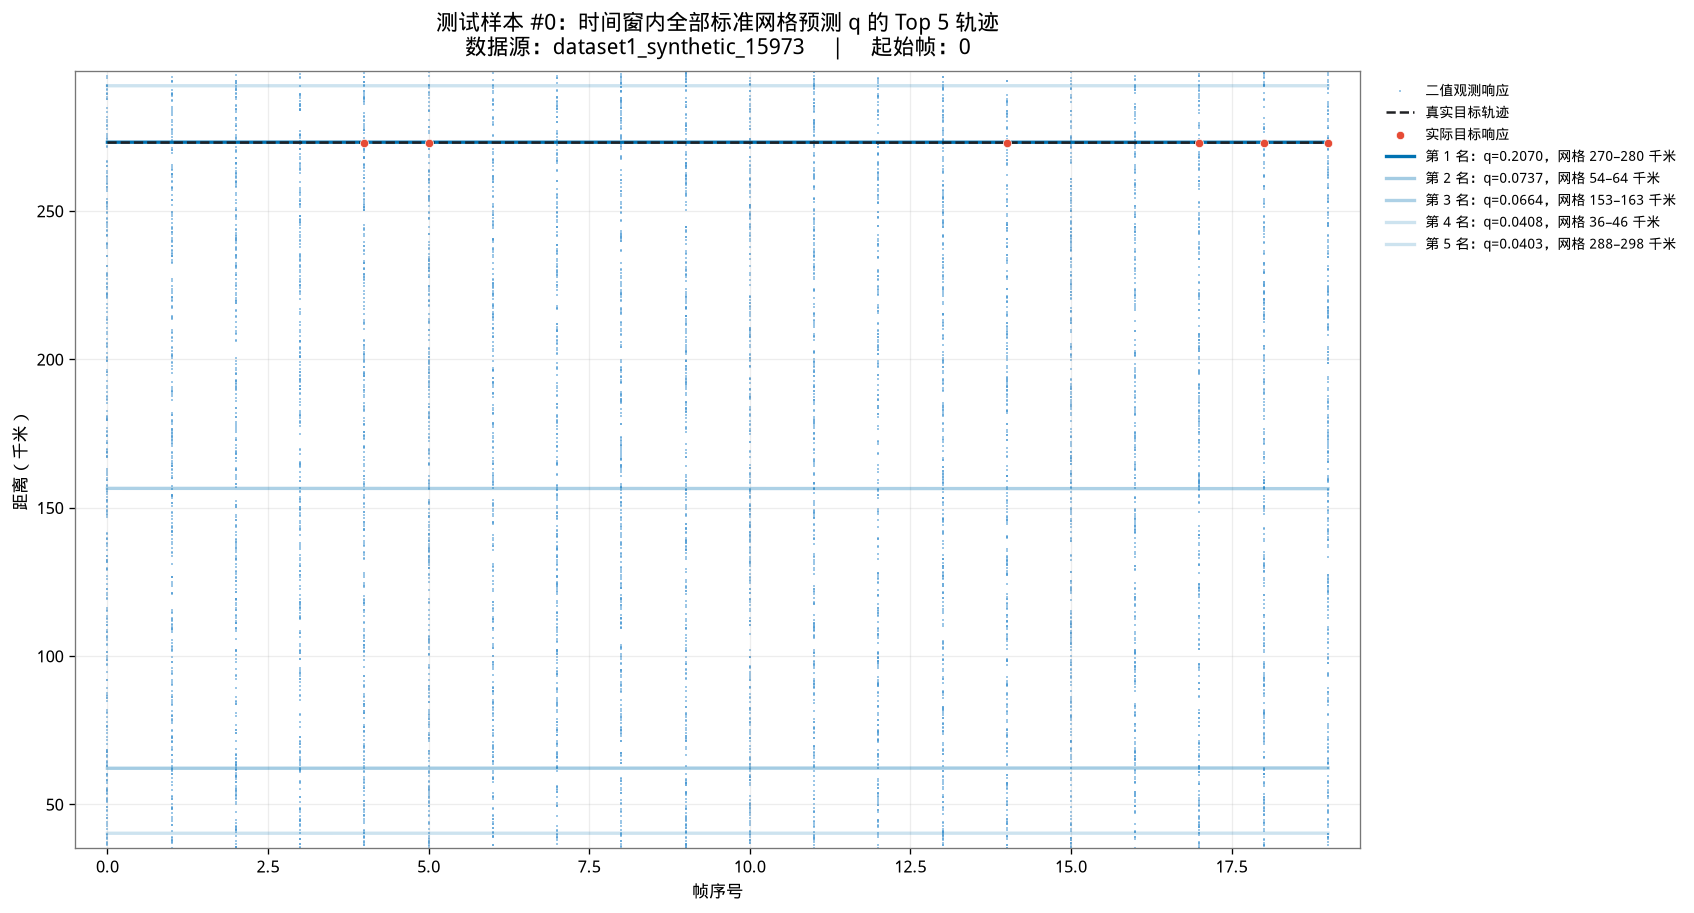

In [130]:
# 设置 test 样本索引、20 帧时间窗起点和需要绘制的 q Top N。
TOP_Q_TEST_SOURCE_INDEX = 0
TOP_Q_TIME_START_FRAME = 0
TOP_Q_LINE_COUNT = 5

top_q_ranking_table, top_q_figure = plot_test_window_top_q(
    source_index=TOP_Q_TEST_SOURCE_INDEX,
    time_start=TOP_Q_TIME_START_FRAME,
    top_n=TOP_Q_LINE_COUNT,
)
